# 2. Model Train

## Model EfficientNet B4

### Import libraries

In [1]:
!pip install tensorflow==2.9

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.7/511.7 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 23.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.7/438.7 kB 22.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 61.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 77.3 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.12.0
    Uninstalling keras-2.12.0:
      Successfully uninstalled keras-2.12.0
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 23.3.3
    Uninstalling flatbuffers-23.3.3:
      Successfully uninstalled flatbuffers-23.3.3
  Attempting unin

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import timeit

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight

In [3]:
np.random.seed(12049)

In [4]:
def get_plot_loss_acc(model, model_name):
    fig = plt.figure()
    plt.subplot(2, 1, 1)
    plt.plot(model.history.history["loss"])
    plt.plot(model.history.history["val_loss"])
    plt.title(f"{model_name} \n\n model loss")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.legend(["train", "valid"], loc="upper right")

    plt.subplot(2, 1, 2)
    plt.plot(model.history.history["accuracy"])
    plt.plot(model.history.history["val_accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "valid"], loc="lower right")

    plt.tight_layout()


def compute_confusion_matrix(
    ytrue, ypred, class_names, model_name
):
    cm = confusion_matrix(
        y_true=ytrue.labels,
        y_pred=np.argmax(ypred, axis=1),
    )

    cmn = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cmn,
        annot=True,
        fmt=".2f",
        cmap="Purples",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show(block=False)


def get_evaluate(data, name, model):
    score_model = model.evaluate(data, verbose=1)
    print(f"{name} loss: {score_model[0]:.2f}")
    print(f"{name} accuracy: {score_model[1]:.2f}")


def get_predict(data, model):
    predict_model = model.predict(data)
    return predict_model


def get_metrics(y_test, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    print(f"Accuracy Score - {model_name}: {acc:.2f}")
    print(f"Balanced Accuracy Score - {model_name}: {bal_acc:.2f}")
    print("\n")

    print(classification_report(y_test, y_pred))

### Load data

In [5]:
base_dir = "/content/drive/MyDrive/dataset/"
train_path = os.path.join(base_dir, 'train')
valid_path = os.path.join(base_dir, 'val')
test_path = os.path.join(base_dir, 'test')

### Definitions

In [6]:
model_name = "EfficientNetB4"
class_names = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']

target_size = (224, 224)
epochs = 100
batch_size = 256
img_shape = (224, 224, 3)

# Save model
save_model_ft = os.path.join('models', f'model_{model_name}_ft.hdf5')

### Image data generator

In [8]:
aug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    horizontal_flip=True,
    brightness_range=[0.3, 0.8],
    width_shift_range=[-50, 0, 50, 30, -30],
    zoom_range=0.1,
    fill_mode="nearest",
)

noaug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
)


In [9]:
train_generator = aug_datagen.flow_from_directory(
    train_path, class_mode="categorical", target_size=target_size, shuffle=True
)

valid_generator = noaug_datagen.flow_from_directory(
    valid_path,
    class_mode="categorical",
    target_size=target_size,
    shuffle=False,
)

Found 2127 images belonging to 5 classes.
Found 354 images belonging to 5 classes.


In [10]:
y_train = train_generator.labels
y_val = valid_generator.labels

### Weight data

In [11]:
unique, counts = np.unique(y_train, return_counts=True)
print("Train: ", dict(zip(unique, counts)))

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
train_class_weights = dict(enumerate(class_weights))
print(train_class_weights)

Train:  {0: 477, 1: 450, 2: 455, 3: 477, 4: 268}
{0: 0.8918238993710692, 1: 0.9453333333333334, 2: 0.934945054945055, 3: 0.8918238993710692, 4: 1.587313432835821}


### Train data

In [12]:
classes = np.unique(y_train)

# Callbacks
early = tf.keras.callbacks.EarlyStopping(
            monitor='loss', min_delta=0.01, patience=8,
            restore_best_weights=True
        )
plateau = tf.keras.callbacks.ReduceLROnPlateau(
                monitor='loss', factor=0.1, min_delta=0.01, 
                min_lr=1e-10, patience=4, mode='auto'
            )
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='accuracy',
                             factor=0.3,
                             patience=2,
                             verbose=1,
                             mode='auto',
                            min_delta=0.001)

In [13]:
model = tf.keras.applications.efficientnet.EfficientNetB4(
    input_shape=(img_shape),
    include_top=False,
    weights="imagenet",
)

71686520/71686520 [==============================] - 4s 0us/step


### Fine-tuning

In [14]:
for layer in model.layers:
    layer.trainable = True

model_ft = tf.keras.models.Sequential(
    [
        model,
   
          tf.keras.layers.BatchNormalization(),

          tf.keras.layers.Activation('relu'),
         tf.keras.layers.GlobalAveragePooling2D(),
        #  tf.keras.layers.Flatten(),
         tf.keras.layers.Dropout(0.2),
         tf.keras.layers.Dense(5, activation="softmax"),
    ]
)

model_ft.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb4 (Functional)  (None, 7, 7, 1792)       17673823  
                                                                 
 batch_normalization (BatchN  (None, 7, 7, 1792)       7168      
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 7, 7, 1792)        0         
                                                                 
 global_average_pooling2d (G  (None, 1792)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1792)              0         
                                                                 
 dense (Dense)               (None, 5)                 8

In [15]:
model_ft.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

start_ft = timeit.default_timer()

history = model_ft.fit(
    train_generator,
    epochs=60,
    batch_size=batch_size,
    callbacks=[early],
    validation_data=valid_generator,
    class_weight=train_class_weights,
    verbose=1,
)

stop_ft = timeit.default_timer()

Epoch 1/60
67/67 [==============================] - 1502s 22s/step - loss: 1.2391 - accuracy: 0.4269 - val_loss: 1.0240 - val_accuracy: 0.5593
Epoch 2/60
67/67 [==============================] - 53s 778ms/step - loss: 0.9085 - accuracy: 0.5703 - val_loss: 1.3679 - val_accuracy: 0.4548
Epoch 3/60
67/67 [==============================] - 53s 779ms/step - loss: 0.8369 - accuracy: 0.6102 - val_loss: 1.0323 - val_accuracy: 0.5960
Epoch 4/60
67/67 [==============================] - 54s 797ms/step - loss: 0.7454 - accuracy: 0.6507 - val_loss: 0.8321 - val_accuracy: 0.6299
Epoch 5/60
67/67 [==============================] - 53s 779ms/step - loss: 0.7209 - accuracy: 0.6704 - val_loss: 1.0255 - val_accuracy: 0.6497
Epoch 6/60
67/67 [==============================] - 53s 789ms/step - loss: 0.6963 - accuracy: 0.6827 - val_loss: 0.8088 - val_accuracy: 0.6497
Epoch 7/60
67/67 [==============================] - 55s 815ms/step - loss: 0.6326 - accuracy: 0.7104 - val_loss: 1.0604 - val_accuracy: 0.5847

In [16]:
model_ft.save("efficientnetb4.hdf5")

In [17]:
execution_time_ft = (stop_ft - start_ft) / 60
print(
    f"Model {model_name} fine tuning executed in {execution_time_ft:.2f} minutes"
)

Model EfficientNetB4 fine tuning executed in 82.18 minutes


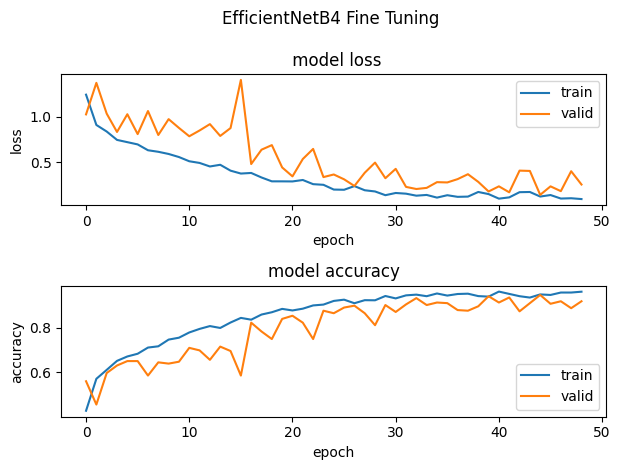

In [18]:
get_plot_loss_acc(model_ft, f"{model_name} Fine Tuning")

In [19]:
get_evaluate(valid_generator, "Valid", model_ft)


12/12 [==============================] - 2s 135ms/step - loss: 0.2388 - accuracy: 0.9124
Valid loss: 0.24
Valid accuracy: 0.91


In [20]:
predict_model_ft = get_predict(valid_generator, model_ft)

get_metrics(
    valid_generator.labels,
    y_pred=np.argmax(predict_model_ft, axis=1),
    model_name=model_name,
)

12/12 [==============================] - 6s 157ms/step
Accuracy Score - EfficientNetB4: 0.91
Balanced Accuracy Score - EfficientNetB4: 0.92


              precision    recall  f1-score   support

           0       0.97      0.90      0.94        80
           1       0.90      0.89      0.90        73
           2       0.94      0.84      0.88        73
           3       0.79      1.00      0.88        67
           4       1.00      0.95      0.97        61

    accuracy                           0.91       354
   macro avg       0.92      0.92      0.91       354
weighted avg       0.92      0.91      0.91       354



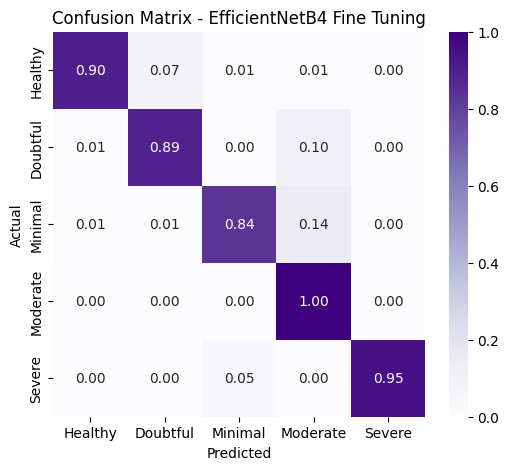

In [21]:
compute_confusion_matrix(
    valid_generator, predict_model_ft, class_names, f"{model_name} Fine Tuning"
)